<h6>
<u>File</u>: clustering_eval.ipynb <br>
<br>
<u>Author</u>: Prabhjot Singh (prabhjot@fnal.gov) <br>
<br>
<u>Goal</u>: an internal notebook to be run by main_cluster_eval.ipynb. It is automatically run. <br>
<br>

### Helper function

In [31]:
import builtins
print = builtins.print

print("")
print("We are ready to start the clustering evaluation process.")
print("We are now running script: clustering_eval.ipynb. This script does the actual work.")
print("We call this script from the main workflow script: main_cluster_eval.ipynb")
print("")


We are ready to start the clustering evaluation process.
We are now running script: clustering_eval.ipynb. This script does the actual work.
We call this script from the main workflow script: main_cluster_eval.ipynb



In [32]:
# skip notebook if missing truth files
SKIP_NOTEBOOK = False   # TODO: what does this do?

print ("Checking for required truth files...")

# helper function to skip notebook execution
def skip_if_needed():
    if globals().get("SKIP_NOTEBOOK", False):
        return True
    return False

Checking for required truth files...


In [65]:
# Configuration parameters
SBNDCODE_VERSION          = "v10_06_00"   # Use the latest version available
PROCESS                   = "nu_spill"    # options: "nu_spill", "cosmic_spill"
evt                       = 3
apa                       = "APA0"        # options: "APA0", "APA1"
radius_efficiency         = 1             # in cm, radius around true point to look for reco points for efficiency calculation
radius_purity_xz          = 1             # in cm, radius in xz plane around reco point to look for true points for purity calculation
radius_purity_yz          = 2             # in cm, radius in yz plane around reco point to look for true points for purity calculation
min_recopoints_threshold  = 5             # Minimum number of reco points within the radius to consider a true point as matched
min_cluster_energy        = 5             # in MeV
min_true_points_cutoff    = 200           # Minimum number of true points in a cluster to consider it for evaluation
min_reco_points_cutoff    = 200           # Minimum number of reco points in a cluster to consider it for evaluation

# Wirecell fiducial volume boundaries (cm)
x_min                     = -250.0
x_max                     = 250.0
y_min                     = -203.3
y_max                     = 200.5
z_min                     = 4.7
z_max                     = 500.6

# Booleans to decide which selections to apply
Apply_energy_cutoff            = True     # Whether to apply energy cutoff on true points
Apply_min_true_points_cutoff   = True     # Whether to apply minimum points cutoff on true clusters
Apply_min_reco_points_cutoff   = True     # Whether to apply minimum points cutoff on reco clusters
Apply_fiducial_volume_cut      = True     # Whether to apply fiducial volume cut on both true and reco points

print("SBNDCODE_VERSION:", SBNDCODE_VERSION)
print("PROCESS:", PROCESS)
print("evt:", evt)
print("apa:", apa)
print("\nReco points threshold:", min_recopoints_threshold, "reco points")
print("Reco points threshold radius:" , radius_efficiency, "cm for efficiency")
print("True points purity radius:", radius_purity_xz, "cm in xz plane and", radius_purity_yz, "cm in yz plane for purity")
print("min_cluster_energy:", min_cluster_energy)
print("min_true_points_cutoff:", min_true_points_cutoff)
print("min_reco_points_cutoff:", min_reco_points_cutoff)
print("Fiducial volume, X:", x_min, "to", x_max, "cm")
print("Fiducial volume, Y:", y_min, "to", y_max, "cm")
print("Fiducial volume, Z:", z_min, "to", z_max, "cm")

print ("\nSelections applied")
if Apply_energy_cutoff:
    print("- Energy cutoff on true points: True")
else:    print("- Energy cutoff on true points: False")
if Apply_min_true_points_cutoff:
    print("- Minimum true points cutoff on clusters: True")
else:    print("- Minimum true points cutoff on clusters: False")
if Apply_min_reco_points_cutoff:  
    print("- Minimum reco points cutoff on clusters: True")
else:    print("- Minimum reco points cutoff on clusters: False")
if Apply_fiducial_volume_cut:
    print("- Fiducial volume cut on points: True")
else:    print("- Fiducial volume cut on points: False")

SBNDCODE_VERSION: v10_06_00
PROCESS: nu_spill
evt: 3
apa: APA0

Reco points threshold: 5 reco points
Reco points threshold radius: 1 cm for efficiency
True points purity radius: 1 cm in xz plane and 2 cm in yz plane for purity
min_cluster_energy: 5
min_true_points_cutoff: 200
min_reco_points_cutoff: 200
Fiducial volume, X: -250.0 to 250.0 cm
Fiducial volume, Y: -203.3 to 200.5 cm
Fiducial volume, Z: 4.7 to 500.6 cm

Selections applied
- Energy cutoff on true points: True
- Minimum true points cutoff on clusters: True
- Minimum reco points cutoff on clusters: True
- Fiducial volume cut on points: True


In [34]:
# List of other important parameters that we will need to pass to the clustering evaluation script
marker_size=1

print("All required parameters are set. We can now proceed to run the clustering evaluation script.")
print("Marker size is set to:", marker_size)

All required parameters are set. We can now proceed to run the clustering evaluation script.
Marker size is set to: 1


In [35]:
# read input and create arrays
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import sys
import os
from scipy.spatial import KDTree

OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/out/")
SUBDIR="24308437_0" # TODO: we need to find a way of not hardcoding this
OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"
else:
  print("\n Incorrect PROCESS.\n\n")

def read_true_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    _e = np.loadtxt(files[5])
    _t = np.loadtxt(files[6])
    return _x, _y, _z, _id, _q, _e, _t

def read_pred_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    return _x, _y, _z, _id, _q 

NEWOUTDIR     = OUTDIR/"xyz-coordinates"    
fx_true_apa0  = NEWOUTDIR / str(evt) / "x_truth_apa0.txt"
fy_true_apa0  = NEWOUTDIR / str(evt) / "y_truth_apa0.txt"
fz_true_apa0  = NEWOUTDIR / str(evt) / "z_truth_apa0.txt"
fq_true_apa0  = NEWOUTDIR / str(evt) / "charge_truth_apa0.txt"
fid_true_apa0 = NEWOUTDIR / str(evt) / "clusterid_truth_apa0.txt"
fe_true_apa0  = NEWOUTDIR / str(evt) / "energy_truth_apa0.txt"
ft_true_apa0  = NEWOUTDIR / str(evt) / "time_truth_apa0.txt"

fx_true_apa1  = NEWOUTDIR / str(evt) / "x_truth_apa1.txt"
fy_true_apa1  = NEWOUTDIR / str(evt) / "y_truth_apa1.txt"
fz_true_apa1  = NEWOUTDIR / str(evt) / "z_truth_apa1.txt"
fq_true_apa1  = NEWOUTDIR / str(evt) / "charge_truth_apa1.txt"
fid_true_apa1 = NEWOUTDIR / str(evt) / "clusterid_truth_apa1.txt"
fe_true_apa1  = NEWOUTDIR / str(evt) / "energy_truth_apa1.txt"
ft_true_apa1  = NEWOUTDIR / str(evt) / "time_truth_apa1.txt"

fx_pred_apa0  = NEWOUTDIR / str(evt) / "x_clustering_apa0.txt"
fy_pred_apa0  = NEWOUTDIR / str(evt) / "y_clustering_apa0.txt"
fz_pred_apa0  = NEWOUTDIR / str(evt) / "z_clustering_apa0.txt"
fq_pred_apa0  = NEWOUTDIR / str(evt) / "charge_clustering_apa0.txt"
fid_pred_apa0 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa0.txt"

fx_pred_apa1  = NEWOUTDIR / str(evt) / "x_clustering_apa1.txt"
fy_pred_apa1  = NEWOUTDIR / str(evt) / "y_clustering_apa1.txt"
fz_pred_apa1  = NEWOUTDIR / str(evt) / "z_clustering_apa1.txt"
fq_pred_apa1  = NEWOUTDIR / str(evt) / "charge_clustering_apa1.txt"
fid_pred_apa1 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa1.txt"

# check for missing or empty truth files
if apa =='APA0':
    if not fx_true_apa0.exists() or os.stat(fx_true_apa0).st_size <= 1:
        print(f"{fx_true_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_true_apa0.exists() or os.stat(fy_true_apa0).st_size<= 1:
        print(f"{fy_true_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_true_apa0.exists() or os.stat(fz_true_apa0).st_size <= 1:
        print(f"{fz_true_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fx_pred_apa0.exists() or os.stat(fx_pred_apa0).st_size <= 1:
        print(f"{fx_pred_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_pred_apa0.exists() or os.stat(fy_pred_apa0).st_size<= 1:
        print(f"{fy_pred_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_pred_apa0.exists() or os.stat(fz_pred_apa0).st_size <= 1:
        print(f"{fz_pred_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
elif apa =='APA1':
    if not fx_true_apa1.exists() or os.stat(fx_true_apa1).st_size <= 1:
        print(f"{fx_true_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_true_apa1.exists() or os.stat(fy_true_apa1).st_size <= 1:
        print(f"{fy_true_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_true_apa1.exists() or os.stat(fz_true_apa1).st_size <= 1:
        print(f"{fz_true_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fx_pred_apa1.exists() or os.stat(fx_pred_apa1).st_size <= 1:
        print(f"{fx_pred_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_pred_apa1.exists() or os.stat(fy_pred_apa1).st_size<= 1:
        print(f"{fy_pred_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_pred_apa1.exists() or os.stat(fz_pred_apa1).st_size <= 1:
        print(f"{fz_pred_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
else:
  print("Incorrect apa.")
    
# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    
    # group files for loading
    true_files_apa0 = [fx_true_apa0, fy_true_apa0, fz_true_apa0, fid_true_apa0, fq_true_apa0, fe_true_apa0, ft_true_apa0]  # Replace with file names
    true_files_apa1 = [fx_true_apa1, fy_true_apa1, fz_true_apa1, fid_true_apa1, fq_true_apa1, fe_true_apa1, ft_true_apa1]  # Replace with file names
    pred_files_apa0 = [fx_pred_apa0, fy_pred_apa0, fz_pred_apa0, fid_pred_apa0, fq_pred_apa0]
    pred_files_apa1 = [fx_pred_apa1, fy_pred_apa1, fz_pred_apa1, fid_pred_apa1, fq_pred_apa1]

    # Define placeholders
    x_true = y_true = z_true = id_true = q_true = e_true = t_true = None
    x_pred = y_pred = z_pred = id_pred = q_pred = None

    # Load the true and predicted coordinates
    if apa =='APA0':
      x_true_apa0, y_true_apa0, z_true_apa0, id_true_apa0, q_true_apa0, e_true_apa0 , t_true_apa0 = read_true_coordinates(true_files_apa0)
      x_pred_apa0, y_pred_apa0, z_pred_apa0, id_pred_apa0, q_pred_apa0                            = read_pred_coordinates(pred_files_apa0)
      
      x_true  = x_true_apa0
      y_true  = y_true_apa0
      z_true  = z_true_apa0
      id_true = id_true_apa0
      q_true  = q_true_apa0
      e_true  = e_true_apa0
      t_true  = t_true_apa0

      x_pred  = x_pred_apa0
      y_pred  = y_pred_apa0
      z_pred  = z_pred_apa0
      id_pred = id_pred_apa0
      q_pred  = q_pred_apa0

    elif apa =='APA1':
      x_true_apa1, y_true_apa1, z_true_apa1, id_true_apa1, q_true_apa1, e_true_apa1, t_true_apa1= read_true_coordinates(true_files_apa1)
      x_pred_apa1, y_pred_apa1, z_pred_apa1, id_pred_apa1, q_pred_apa1                          = read_pred_coordinates(pred_files_apa1)
      
      x_true  = x_true_apa1
      y_true  = y_true_apa1
      z_true  = z_true_apa1
      id_true = id_true_apa1
      q_true  = q_true_apa1   
      e_true  = e_true_apa1
      t_true  = t_true_apa1

      x_pred  = x_pred_apa1
      y_pred  = y_pred_apa1
      z_pred  = z_pred_apa1
      id_pred = id_pred_apa1
      q_pred  = q_pred_apa1

    else:
      print("Incorrect apa.") 

In [36]:
# Directory for saving plots
PLOTDIR = NEWOUTDIR / str(evt)/ "plots"
# make this directory if it doesn't exist
PLOTDIR.mkdir(parents=True, exist_ok=True)
print("Plot directory:", PLOTDIR)

Plot directory: /exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/out/24308437_0/v10_06_00/nu_spill/xyz-coordinates/3/plots


In [37]:
# In this block, we evaluate the true energy per cluster by adding up the e_true values for each unique id_true.
# Then we apply a minimum cluster energy cut (min_cluster_energy) to filter out low-energy clusters.

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    
    # apply energy cutoff for each true cluster
    true_5d_points = np.column_stack((x_true, y_true, z_true, id_true, q_true, e_true))

    # Compute sum of e_true per cluster (grouped by id_true)
    cluster_sums = {}
    for point in true_5d_points:
        cluster_sums[point[3]] = cluster_sums.get(point[3], 0) + point[5]  # id_true at index 3, e_true at index 5

    # Filter points, keeping only clusters where sum(e_true) >= min_cluster_energy
    true_5d_points = np.array([point for point in true_5d_points if cluster_sums[point[3]] >= min_cluster_energy])

    # skip if no truth clusters with min_cluster_energy
    if(len(true_5d_points)==0):
        SKIP_NOTEBOOK = True

    print(len(true_5d_points) , "true points after energy cut of", min_cluster_energy, "nelectrons")
    print("Structure of true_5d_points:", true_5d_points.shape)


25448 true points after energy cut of 5 nelectrons
Structure of true_5d_points: (25448, 6)


In [38]:
# Function to apply fiducial volume cut to true points (6D array: x, y, z, id, q, e)
def apply_fiducial_volume_cut_true(true_points):
    filtered_points = []
    for point in true_points:
        x, y, z = point[0], point[1], point[2]
        if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
            filtered_points.append(point)
    return np.array(filtered_points) if filtered_points else np.array([]).reshape(0, 6)

# Function to apply fiducial volume cut to reco points (5D array: x, y, z, id, q)
def apply_fiducial_volume_cut_reco(reco_points):
    filtered_points = []
    for point in reco_points:
        x, y, z = point[0], point[1], point[2]
        if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
            filtered_points.append(point)
    return np.array(filtered_points) if filtered_points else np.array([]).reshape(0, 5)

In [39]:
# Apply fiducial volume cut to true points
if(Apply_fiducial_volume_cut):
    print(f"Number of true points before fiducial volume cut: {len(true_5d_points)}")
    true_5d_points = apply_fiducial_volume_cut_true(true_5d_points)
    print(f"Number of true points after fiducial volume cut: {len(true_5d_points)}")
    
    # skip if no truth clusters after fiducial cut
    if(len(true_5d_points)==0):
        SKIP_NOTEBOOK = True

Number of true points before fiducial volume cut: 25448
Number of true points after fiducial volume cut: 25233


In [40]:
# In this block, we re-assign the cluster ID of each true point to be the average x-position of its cluster.
# This is done to facilitate comparison with predicted clusters.
# This way each cluster ID corresponds to a average x-position (drift time) of the cluster.

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:

    # re-assign cluster ID to be the average x-position of the cluster
    import numpy as np

    # Group points by ID and compute average x for each cluster
    clusters = {}
    for point in true_5d_points:   
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)

    # Compute new cluster IDs based on average x position
    new_points = []
    for cluster_id, points in clusters.items():
        points = np.array(points)
        avg_x = np.mean(points[:, 0])  # Compute average x-position, 0 is x-coordinate index
        # convert avg_x to nearest integer (since x is in cm, we can round to nearest cm)
        avg_x = round(avg_x)
        if points[:, 4].any() == 1:
            avg_x = 9999
        else:
            avg_x = round(avg_x)
        points[:, 3] = avg_x  # Reassign cluster ID to avg_x, because index 3 is cluster ID
        new_points.append(points)
        print("Cluster ID:", cluster_id, "Average x:", avg_x, "Number of points in cluster:", len(points))

    # Flatten list into a NumPy array
    true_5d_points = np.vstack(new_points)

    print("After re-assinging, we still have ", len(true_5d_points), " true points in ", len(clusters), " clusters, with structure", true_5d_points.shape)


Cluster ID: 181.0 Average x: 24 Number of points in cluster: 829
Cluster ID: 110.0 Average x: -210 Number of points in cluster: 3446
Cluster ID: 108.0 Average x: 18 Number of points in cluster: 696
Cluster ID: 261496.0 Average x: -8 Number of points in cluster: 97
Cluster ID: 261770.0 Average x: -46 Number of points in cluster: 107
Cluster ID: 83.0 Average x: -224 Number of points in cluster: 1132
Cluster ID: 74.0 Average x: 6 Number of points in cluster: 5753
Cluster ID: 49.0 Average x: -24 Number of points in cluster: 10963
Cluster ID: 43.0 Average x: -1 Number of points in cluster: 1470
Cluster ID: 461865.0 Average x: -18 Number of points in cluster: 740
After re-assinging, we still have  25233  true points in  10  clusters, with structure (25233, 6)


In [41]:
# Lets define the true clusters
# Give different color for each cluster

# Group points by ID and draw each true cluster by a different color
clusters_true = {}
for point in true_5d_points:   
    cluster_id = point[3]  # Original cluster ID
    if cluster_id not in clusters_true:
        clusters_true[cluster_id] = []
    clusters_true[cluster_id].append(point)

for cluster_id, points in clusters_true.items():
    points = np.array(points)
    true_x_cluster = points[:, 0]
    true_z_cluster = points[:, 2]


In [42]:
# Now we do the same re-assignment of cluster IDs for the predicted points.

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:

    # re-assign cluster ID to be the average x-position
    import numpy as np

    # These were previously selected and stored
    predicted_5d_points = np.column_stack((x_pred, y_pred, z_pred, id_pred, q_pred))

    # Group points by ID and compute average x for each cluster
    clusters = {}
    for point in predicted_5d_points:
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)

    # Compute new cluster IDs based on average x position
    new_points = []
    for cluster_id, points in clusters.items():
        points          = np.array(points)
        avg_x           = np.mean(points[:, 0] + points[:, 1])  # Compute average x-position
        # convert avg_x to nearest integer (since x is in cm, we can round to nearest cm)
        avg_x = round(avg_x)
        points[:, 3]    = avg_x  # Reassign cluster ID to avg_x
        new_points.append(points)

    # Flatten list into a NumPy array
    predicted_5d_points = np.vstack(new_points)

    print("After re-assinging, we have ", len(predicted_5d_points), " predicted points in ", len(clusters), " clusters.")

After re-assinging, we have  7296  predicted points in  12  clusters.


In [43]:
# define reco clusters
# Give different color to each reco cluster

# Group points by ID and draw each reco cluster by a different color
clusters_reco = {}
for point in predicted_5d_points:   
    cluster_id = point[3]  # Original cluster ID
    if cluster_id not in clusters_reco:
        clusters_reco[cluster_id] = []
    clusters_reco[cluster_id].append(point)

new_points = []
for cluster_id, points in clusters_reco.items():
    points = np.array(points)
    reco_x_cluster = points[:, 0]
    reco_z_cluster = points[:, 2]

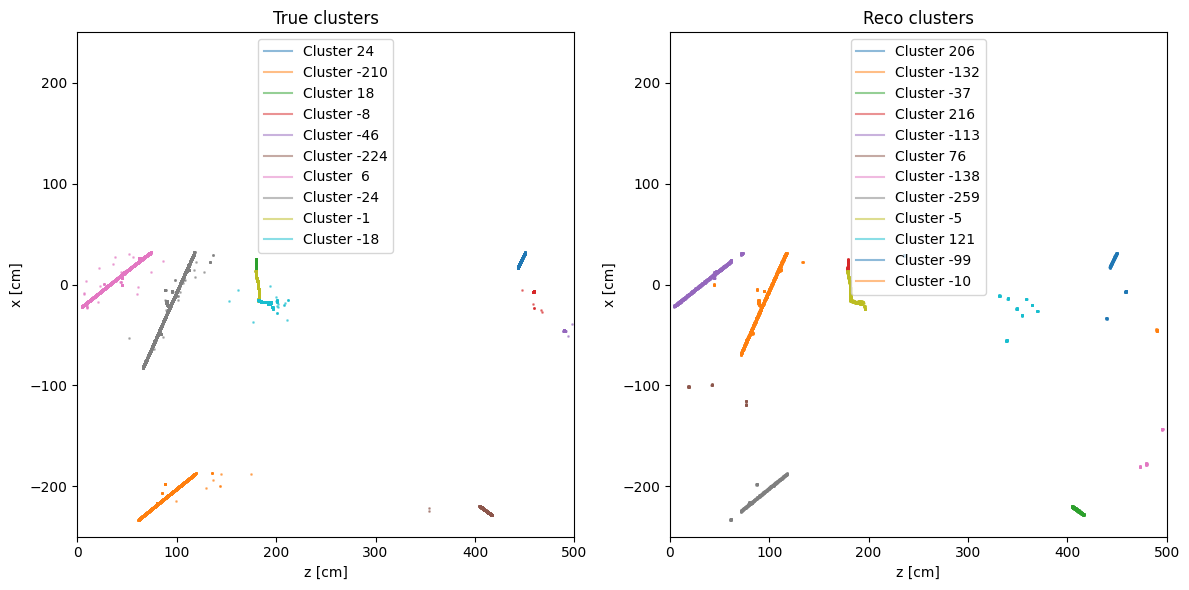

In [44]:
# Lets draw the true and the reco clusters together in the same plot to visually compare them. We will use different colors for true and reco clusters.
# Draw true and reco clusters together
# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
# First scatter plot (left)
axes[0].set_xlim(0, 500)  # Set x-axis range
axes[0].set_ylim(-250, 250)  # Set y-axis range
axes[0].set_xlabel("z [cm]")
axes[0].set_ylabel("x [cm]")
axes[0].set_title("True clusters")
# Draw true clusters in the first subplot
for cluster_id, points in clusters_true.items():
    points = np.array(points)
    true_x_cluster = points[:, 0]
    true_z_cluster = points[:, 2]
    scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=marker_size, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
axes[0].legend()
# Second scatter plot (right)
axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
axes[1].set_xlabel("z [cm]")
axes[1].set_ylabel("x [cm]")
axes[1].set_title("Reco clusters")
# Draw reco clusters in the second subplot
for cluster_id, points in clusters_reco.items():
    points = np.array(points)
    reco_x_cluster = points[:, 0]
    reco_z_cluster = points[:, 2]
    scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
axes[1].legend()
# Adjust layout and show plot
plt.tight_layout()
plt.savefig(PLOTDIR / f"clusters_comparison_evt{evt}_{apa}.png")
plt.show(block=False)



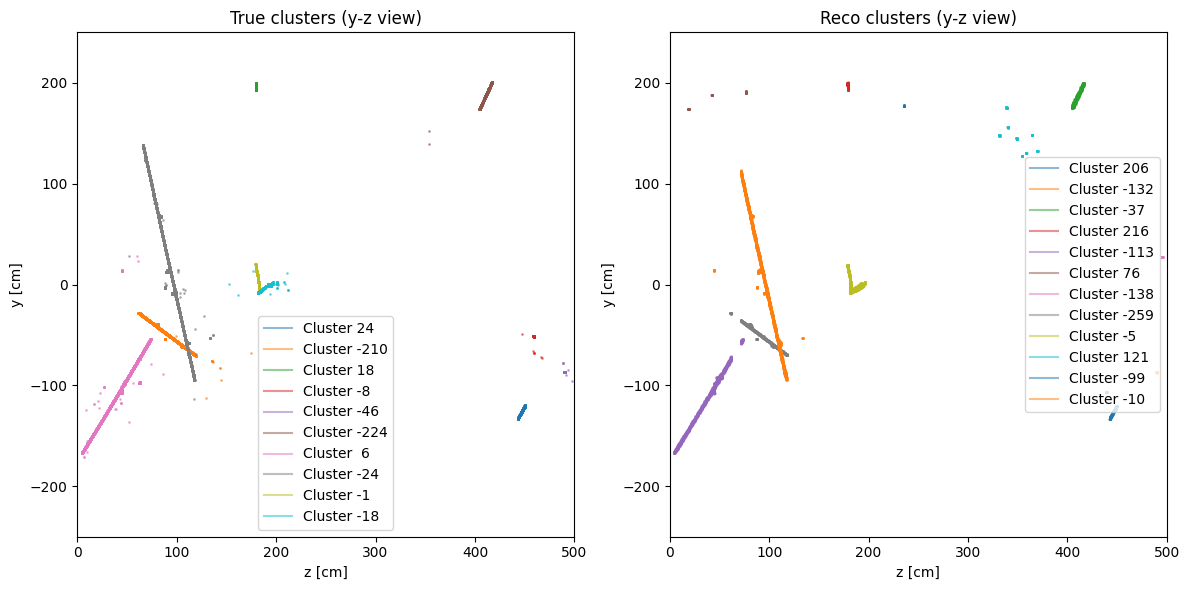

In [45]:
# Draw y-z view

# decide whether to draw y-z or not
draw_yz = True

if draw_yz:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
    # First scatter plot (left)
    axes[0].set_xlim(0, 500)  # Set x-axis range
    axes[0].set_ylim(-250, 250)  # Set y-axis range
    axes[0].set_xlabel("z [cm]")
    axes[0].set_ylabel("y [cm]")
    axes[0].set_title("True clusters (y-z view)")
    # Draw true clusters in the first subplot
    for cluster_id, points in clusters_true.items():
        points = np.array(points)
        true_x_cluster = points[:, 1]
        true_z_cluster = points[:, 2]
        scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[0].legend()
    # Second scatter plot (right)
    axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
    axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
    axes[1].set_xlabel("z [cm]")
    axes[1].set_ylabel("y [cm]")
    axes[1].set_title("Reco clusters (y-z view)")
    # Draw reco clusters in the second subplot
    for cluster_id, points in clusters_reco.items():
        points = np.array(points)
        reco_x_cluster = points[:, 1]
        reco_z_cluster = points[:, 2]
        scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[1].legend()
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show(block=False)
    # save image
    image_path = NEWOUTDIR / f"clusters_evt{evt}_{apa}_view_yz.png"
else:
    print("We are not drawing y-z view")


In [46]:
# Function to apply minimum true points cutoff
def apply_min_true_points_cutoff(true_points, min_points):
    cluster_counts = {}
    for point in true_points:
        cluster_id = point[3]
        cluster_counts[cluster_id] = cluster_counts.get(cluster_id, 0) + 1
    
    true_points = np.array([point for point in true_points if cluster_counts[point[3]] >= min_points])
    return true_points

In [47]:
# call function to apply minimum true points cutoff for each true cluster
if(Apply_min_true_points_cutoff):
    print("Number of true clusters before minimum points cutoff:", len(set(true_5d_points[:, 3])))
    print(f"Number of true points before minimum points cutoff: {len(true_5d_points)}")
    true_5d_points = apply_min_true_points_cutoff(true_5d_points, min_true_points_cutoff)
    print("Number of true clusters after minimum points cutoff:", len(set(true_5d_points[:, 3])))
    print(f"Number of true points after minimum points cutoff: {len(true_5d_points)}")
    clusters_true = {}
    for point in true_5d_points:   
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters_true:
            clusters_true[cluster_id] = []
        clusters_true[cluster_id].append(point)

Number of true clusters before minimum points cutoff: 10
Number of true points before minimum points cutoff: 25233
Number of true clusters after minimum points cutoff: 8
Number of true points after minimum points cutoff: 25029


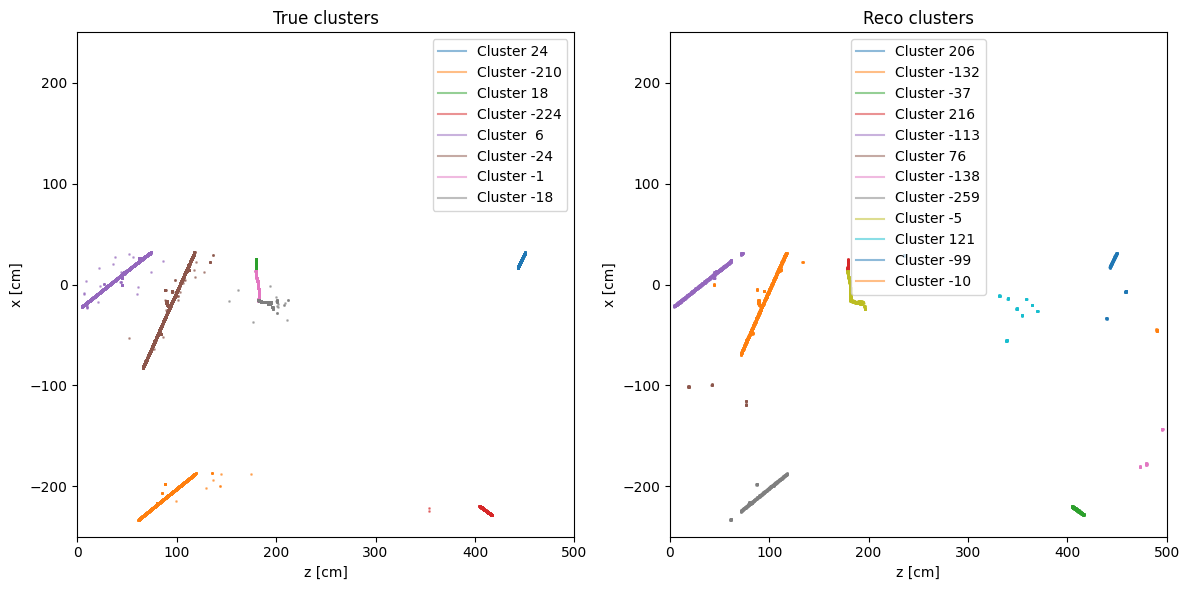

In [48]:
# Lets draw the true and the reco clusters after applying the minimum true points cutoff, together in the same plot to visually compare them. We will use different colors for true and reco clusters.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
# First scatter plot (left)
axes[0].set_xlim(0, 500)  # Set x-axis range
axes[0].set_ylim(-250, 250)  # Set y-axis range
axes[0].set_xlabel("z [cm]")
axes[0].set_ylabel("x [cm]")
axes[0].set_title("True clusters")
# Draw true clusters in the first subplot
for cluster_id, points in clusters_true.items():
    points = np.array(points)
    true_x_cluster = points[:, 0]
    true_z_cluster = points[:, 2]
    scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=marker_size, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
axes[0].legend()
# Second scatter plot (right)
axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
axes[1].set_xlabel("z [cm]")
axes[1].set_ylabel("x [cm]")
axes[1].set_title("Reco clusters")
# Draw reco clusters in the second subplot
for cluster_id, points in clusters_reco.items():
    points = np.array(points)
    reco_x_cluster = points[:, 0]
    reco_z_cluster = points[:, 2]
    scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
axes[1].legend()
# Adjust layout and show plot
plt.tight_layout()
plt.savefig(PLOTDIR / f"clusters_comparison_evt{evt}_{apa}.png")
plt.show(block=False)



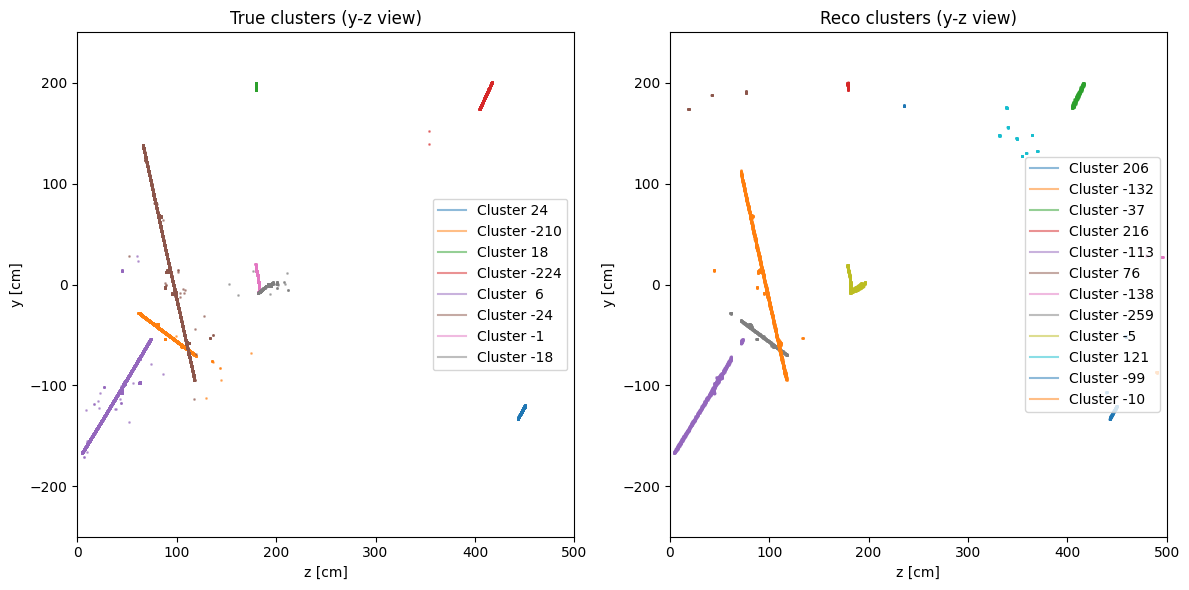

In [49]:
# Draw y-z view
# # Lets draw the true and the reco clusters after applying the minimum true points cutoff, together in the same plot to visually compare them. We will use different colors for true and reco clusters.

# decide whether to draw y-z or not
draw_yz = True

if draw_yz:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
    # First scatter plot (left)
    axes[0].set_xlim(0, 500)  # Set x-axis range
    axes[0].set_ylim(-250, 250)  # Set y-axis range
    axes[0].set_xlabel("z [cm]")
    axes[0].set_ylabel("y [cm]")
    axes[0].set_title("True clusters (y-z view)")
    # Draw true clusters in the first subplot
    for cluster_id, points in clusters_true.items():
        points = np.array(points)
        true_x_cluster = points[:, 1]
        true_z_cluster = points[:, 2]
        scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[0].legend()
    # Second scatter plot (right)
    axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
    axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
    axes[1].set_xlabel("z [cm]")
    axes[1].set_ylabel("y [cm]")
    axes[1].set_title("Reco clusters (y-z view)")
    # Draw reco clusters in the second subplot
    for cluster_id, points in clusters_reco.items():
        points = np.array(points)
        reco_x_cluster = points[:, 1]
        reco_z_cluster = points[:, 2]
        scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[1].legend()
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show(block=False)
    # save image
    image_path = NEWOUTDIR / f"clusters_evt{evt}_{apa}_view_yz.png"
else:
    print("We are not drawing y-z view")


In [50]:
# Function to apply minimum reco points cutoff for reco clusters
def apply_min_reco_points_cutoff(reco_points, min_points):
    cluster_counts = {}
    for point in reco_points:
        cluster_id = point[3]
        cluster_counts[cluster_id] = cluster_counts.get(cluster_id, 0) + 1
    
    reco_points = np.array([point for point in reco_points if cluster_counts[point[3]] >= min_points])
    return reco_points

In [51]:
# call function to apply minimum recopoints cutoff for each reco cluster
if(Apply_min_reco_points_cutoff):
    print(f"Number of reco points before minimum points cutoff: {len(predicted_5d_points)}")
    print(f"Number of reco clusters before minimum points cutoff: {len(set(predicted_5d_points[:, 3]))}")
    predicted_5d_points = apply_min_reco_points_cutoff(predicted_5d_points, min_reco_points_cutoff)
    print(f"Number of reco points after minimum points cutoff: {len(predicted_5d_points)}")
    print(f"Number of reco clusters after minimum points cutoff: {len(set(predicted_5d_points[:, 3]))}")
    clusters_reco = {}
    for point in predicted_5d_points:
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters_reco:
            clusters_reco[cluster_id] = []
        clusters_reco[cluster_id].append(point)
        

Number of reco points before minimum points cutoff: 7296
Number of reco clusters before minimum points cutoff: 12
Number of reco points after minimum points cutoff: 6850
Number of reco clusters after minimum points cutoff: 6


In [52]:
# Apply fiducial volume cut to reco points
if(Apply_fiducial_volume_cut):
    print(f"Number of reco points before fiducial volume cut: {len(predicted_5d_points)}")
    predicted_5d_points = apply_fiducial_volume_cut_reco(predicted_5d_points)
    print(f"Number of reco points after fiducial volume cut: {len(predicted_5d_points)}")
    clusters_reco = {}
    for point in predicted_5d_points:
        cluster_id = point[3]
        if cluster_id not in clusters_reco:
            clusters_reco[cluster_id] = []
        clusters_reco[cluster_id].append(point)

Number of reco points before fiducial volume cut: 6850
Number of reco points after fiducial volume cut: 6836


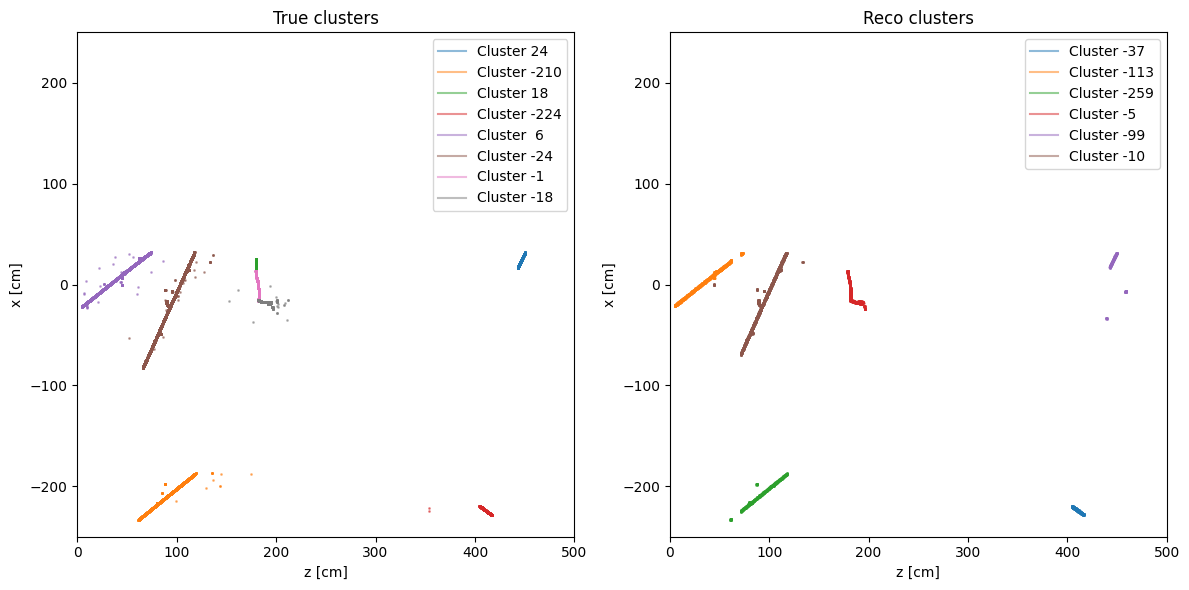

In [53]:
# Lets draw the true and the reco clusters after applying the minimum reco points cutoff, together in the same plot to visually compare them. We will use different colors for true and reco clusters.

fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
# First scatter plot (left)
axes[0].set_xlim(0, 500)  # Set x-axis range
axes[0].set_ylim(-250, 250)  # Set y-axis range
axes[0].set_xlabel("z [cm]")
axes[0].set_ylabel("x [cm]")
axes[0].set_title("True clusters")
# Draw true clusters in the first subplot
for cluster_id, points in clusters_true.items():
    points = np.array(points)
    true_x_cluster = points[:, 0]
    true_z_cluster = points[:, 2]
    scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=marker_size, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
axes[0].legend()
# Second scatter plot (right)
axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
axes[1].set_xlabel("z [cm]")
axes[1].set_ylabel("x [cm]")
axes[1].set_title("Reco clusters")
# Draw reco clusters in the second subplot
for cluster_id, points in clusters_reco.items():
    points = np.array(points)
    reco_x_cluster = points[:, 0]
    reco_z_cluster = points[:, 2]
    scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
axes[1].legend()
# Adjust layout and show plot
plt.tight_layout()
plt.savefig(PLOTDIR / f"clusters_comparison_evt{evt}_{apa}.png")
plt.show(block=False)



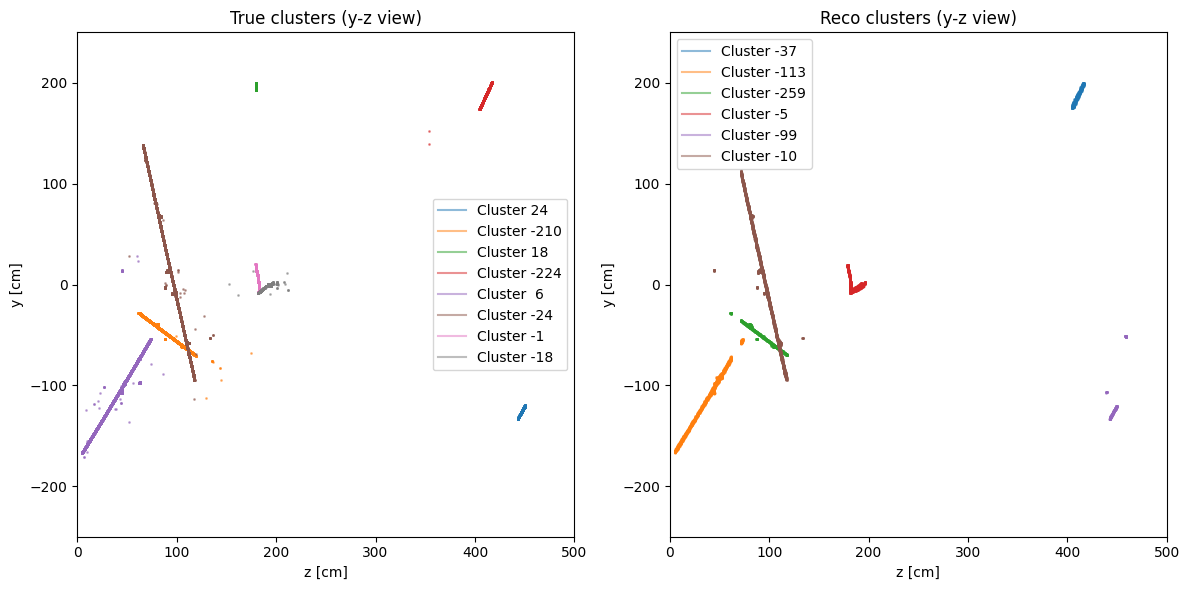

In [54]:
# Draw y-z view
# after reco minimum points cutoff, we can draw the y-z view again to see how it looks

# decide whether to draw y-z or not
draw_yz = True

if draw_yz:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
    # First scatter plot (left)
    axes[0].set_xlim(0, 500)  # Set x-axis range
    axes[0].set_ylim(-250, 250)  # Set y-axis range
    axes[0].set_xlabel("z [cm]")
    axes[0].set_ylabel("y [cm]")
    axes[0].set_title("True clusters (y-z view)")
    # Draw true clusters in the first subplot
    for cluster_id, points in clusters_true.items():
        points = np.array(points)
        true_x_cluster = points[:, 1]
        true_z_cluster = points[:, 2]
        scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[0].legend()
    # Second scatter plot (right)
    axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
    axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
    axes[1].set_xlabel("z [cm]")
    axes[1].set_ylabel("y [cm]")
    axes[1].set_title("Reco clusters (y-z view)")
    # Draw reco clusters in the second subplot
    for cluster_id, points in clusters_reco.items():
        points = np.array(points)
        reco_x_cluster = points[:, 1]
        reco_z_cluster = points[:, 2]
        scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[1].legend()
    # Adjust layout and show plot
    plt.tight_layout()
    plt.show(block=False)
    # save image
    image_path = NEWOUTDIR / f"clusters_evt{evt}_{apa}_view_yz.png"
else:
    print("We are not drawing y-z view")


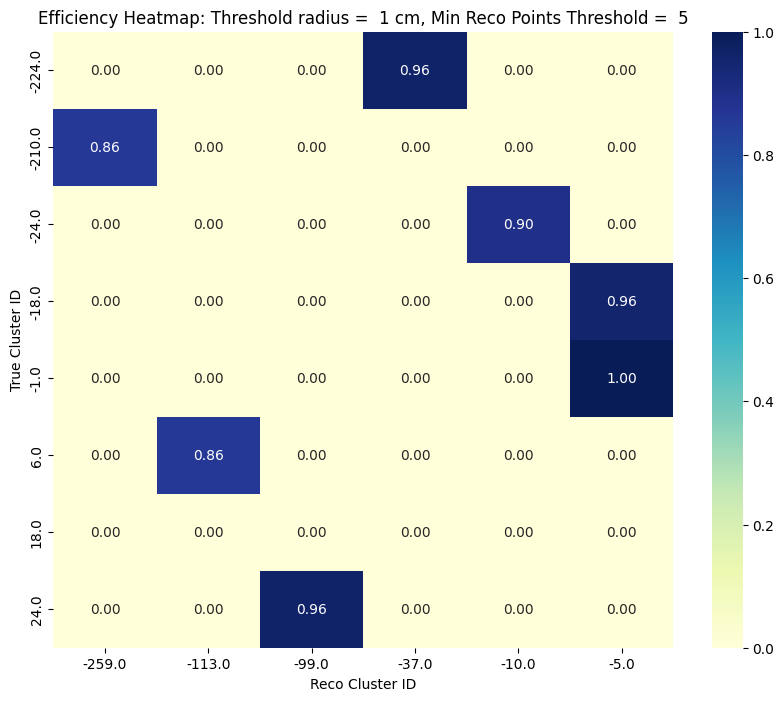

In [55]:
# Lets recalculate efficiency
# for radius 1 cm and 5 or more neighbors and make a heatmap of efficiency values for all true and reco cluster pairs

# Create a list to store efficiency results for each true cluster
efficiency_results = []

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        indices = reco_tree.query_ball_point(true_coords, r=radius_efficiency)  # Find all neighbors within radius
        # Count the number of neighbors for each true point
        num_neighbors = [len(neighbors) for neighbors in indices]
        # Check how many true points are within the radius of any predicted point
        matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap: Threshold radius = {radius_efficiency:2.4g} cm, Min Reco Points Threshold = {min_recopoints_threshold:2.4g}")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
plt.show(block=False)


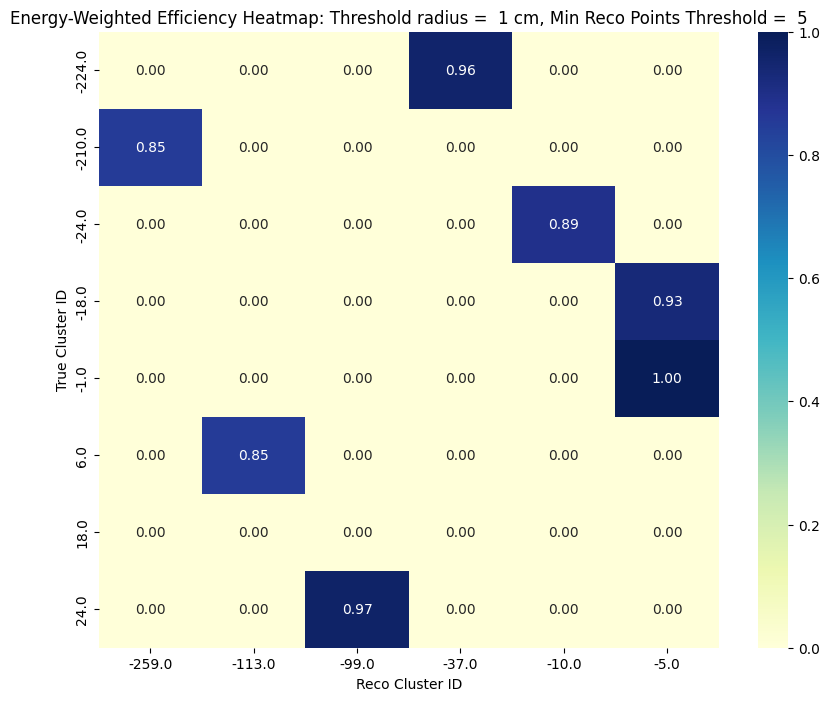

In [56]:
# lets re-weight our true points by energy of the points and then do the same efficiency calculation as above to see if it improves the matching between true and reco clusters
# lets reweight true points by energy

# Create a list to store efficiency results for each true cluster
efficiency_results = []

# save energies of true clusters
matched_true_cluster_energy = []
total_true_cluster_energy = []

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    true_energies = true_points[:, 5]  # Assuming energy is the 6th column

    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]

        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)

        # Query the KDTree with the true points to find nearest neighbors
        indices = reco_tree.query_ball_point(true_coords, r=radius_efficiency)  # Find all neighbors within radius

        # Count the number of neighbors for each true point
        num_neighbors = [len(neighbors) for neighbors in indices]

        # Check how many true points are within the radius of any predicted point and reweight by energy
        matched_true_points_energy = np.sum([true_energies[i] for i, neighbors in enumerate(indices) if len(neighbors) > min_recopoints_threshold])
        matched_true_cluster_energy.append(matched_true_points_energy)

        total_true_energy = np.sum(true_energies)
        total_true_cluster_energy.append(total_true_energy)

        efficiency_energy_weighted = matched_true_points_energy / total_true_energy if total_true_energy > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_energy': matched_true_points_energy,
            'total_true_energy': total_true_energy,
            'efficiency_energy_weighted': efficiency_energy_weighted
        })


# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix_energy_weighted = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency_energy_weighted').fillna(0)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix_energy_weighted, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Energy-Weighted Efficiency Heatmap: Threshold radius = {radius_efficiency:2.4g} cm, Min Reco Points Threshold = {min_recopoints_threshold:2.4g}")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
plt.savefig(PLOTDIR / f"efficiency_heatmap_energy_weighted_evt{evt}_{apa}.png")
plt.show(block=False)

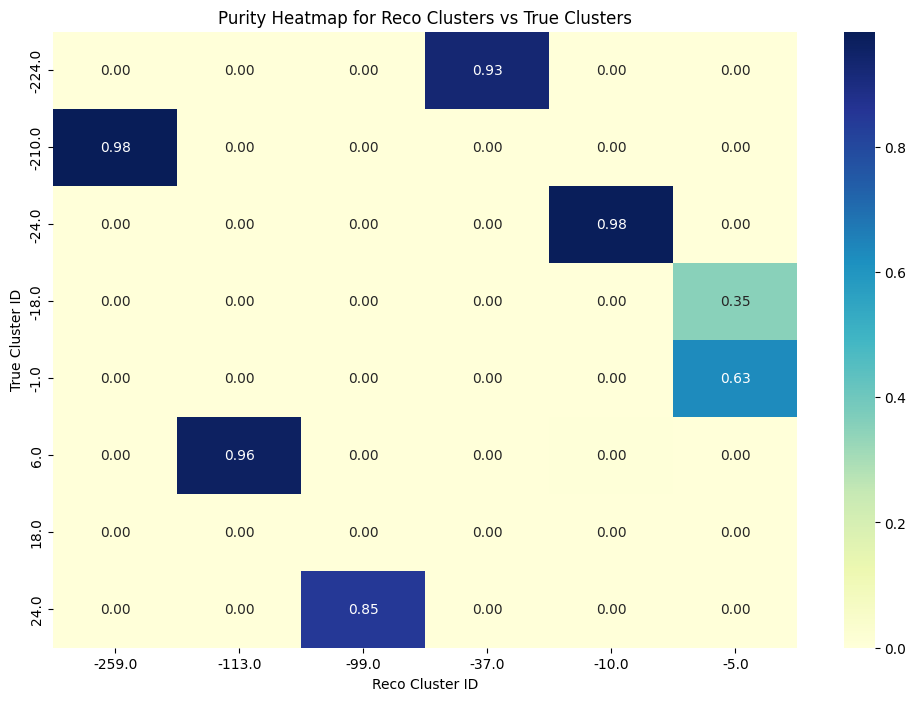

In [57]:
# Now lets calculate purity for each reco cluster and make a heatmap of purity values for all true and reco cluster pairs
# Create a list to store purity results for each reco cluster
purity_results = []

# Loop over each reco cluster
for reco_cluster_id, reco_points in clusters_reco.items():
    reco_points = np.array(reco_points)
    reco_coords = reco_points[:, :3]
    reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction

    # loop over each true cluster
    for true_cluster_id, true_points in clusters_true.items():
        true_points = np.array(true_points)
        true_coords = true_points[:, :3]

        # Build KDTree for the true cluster
        true_tree = KDTree(true_coords)

        # Query the KDTree with the predicted points to find nearest true point
        distances, indices = true_tree.query(reco_coords, k=1)

        nearest_points = true_coords[indices]
        xz_projection = np.sqrt((nearest_points[:, 0] - reco_coords[:, 0])**2 + (nearest_points[:, 2] - reco_coords[:, 2])**2)
        yz_projection = np.sqrt((nearest_points[:, 1] - reco_coords[:, 1])**2 + (nearest_points[:, 2] - reco_coords[:, 2])**2)

        # Apply distance cuts to determine matched reco points
        matched_reco_points = reco_coords[(xz_projection <= radius_purity_xz) & (yz_projection <= radius_purity_yz)]
        total_reco_points = len(reco_coords)
        purity = len(matched_reco_points) / total_reco_points if total_reco_points > 0 else 0

        # Store the purity result for this cluster pair
        purity_results.append({
            'reco_cluster_id': reco_cluster_id,
            'true_cluster_id': true_cluster_id,
            'matched_reco_points': len(matched_reco_points),
            'total_reco_points': total_reco_points,
            'purity': purity
        })
# Convert purity results to a DataFrame for easier analysis
purity_df = pd.DataFrame(purity_results)
# Create a pivot table for the heatmap
heatmap_data = purity_df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='purity')
# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Purity Heatmap for Reco Clusters vs True Clusters")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
plt.savefig(PLOTDIR / f"purity_heatmap_evt{evt}_{apa}.png")
plt.show(block=False)
    


In [58]:
# lets re-pair true and reco clusters who have a higher efficiency. We can then later use this true-reco pair for further analysis
# Create a list to store paired clusters
matched_pairs = df[df['efficiency_energy_weighted'] > 0][['true_cluster_id', 'reco_cluster_id', 'efficiency_energy_weighted']]
matched_pairs = matched_pairs.sort_values(by='efficiency_energy_weighted', ascending=False)
print("Matched true-reco cluster pairs with non-zero efficiency:")
print(matched_pairs)

Matched true-reco cluster pairs with non-zero efficiency:
    true_cluster_id  reco_cluster_id  efficiency_energy_weighted
39             -1.0             -5.0                    1.000000
4              24.0            -99.0                    0.965628
18           -224.0            -37.0                    0.957195
45            -18.0             -5.0                    0.933215
35            -24.0            -10.0                    0.892514
25              6.0           -113.0                    0.853051
8            -210.0           -259.0                    0.852286
29              6.0            -10.0                    0.002613


In [59]:
# lets re-pair true and reco clusters who have a purity value. We can then later use this true-reco pair for further analysis
# Filter out pairs with non-zero purity
matched_pairs = purity_df[purity_df['purity'] > 0]
# For each true cluster, find the reco cluster with the highest purity
best_matches = matched_pairs.loc[matched_pairs.groupby('true_cluster_id')['purity'].idxmax()]
# Display the best matches
print("Best True-Reco Cluster Matches based on Purity:")
print(best_matches[['true_cluster_id', 'reco_cluster_id', 'purity']])


Best True-Reco Cluster Matches based on Purity:
    true_cluster_id  reco_cluster_id    purity
3            -224.0            -37.0  0.926714
17           -210.0           -259.0  0.983471
45            -24.0            -10.0  0.978207
31            -18.0             -5.0  0.350000
30             -1.0             -5.0  0.627273
12              6.0           -113.0  0.961893
32             24.0            -99.0  0.846154


In [60]:
# for above pairs get the efficiencies
# Create a list to store efficiency results for each matched pair
efficiency_results = []
# Loop over each matched pair to calculate efficiency
for _, row in best_matches.iterrows():
    true_cluster_id = row['true_cluster_id']
    reco_cluster_id = row['reco_cluster_id']
    true_points = np.array(clusters_true[true_cluster_id])
    reco_points = np.array(clusters_reco[reco_cluster_id])
    true_coords = true_points[:, :3]
    reco_coords = reco_points[:, :3]
    reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction

    # Build KDTree for the predicted cluster
    reco_tree = KDTree(reco_coords)

    # Query the KDTree with the true points to find nearest neighbors
    indices = reco_tree.query_ball_point(true_coords, r=radius_efficiency)  # Find all neighbors within radius

    # Count the number of neighbors for each true point
    num_neighbors = [len(neighbors) for neighbors in indices]

    # Check how many true points are within the radius of any predicted point
    matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold) 
    total_true_points = len(true_points)
    efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0

    efficiency_results.append({
        'true_cluster_id': true_cluster_id,
        'reco_cluster_id': reco_cluster_id,
        'matched_true_points': matched_true_points,
        'total_true_points': total_true_points,
        'efficiency': efficiency
    })
# Convert efficiency results to a DataFrame for easier analysis
efficiency_df = pd.DataFrame(efficiency_results)
# Display the efficiency results
print("Efficiency for Best True-Reco Cluster Matches:")
print(efficiency_df[['true_cluster_id', 'reco_cluster_id', 'efficiency']])


Efficiency for Best True-Reco Cluster Matches:
   true_cluster_id  reco_cluster_id  efficiency
0           -224.0            -37.0    0.970848
1           -210.0           -259.0    0.869704
2            -24.0            -10.0    0.897929
3            -18.0             -5.0    0.950000
4             -1.0             -5.0    1.000000
5              6.0           -113.0    0.874674
6             24.0            -99.0    0.990350


Performance Dictionary for True-Reco Cluster Pairs:
   true_cluster_id  reco_cluster_id    purity  efficiency
0           -224.0            -37.0  0.926714    0.970848
1           -210.0           -259.0  0.983471    0.869704
2            -24.0            -10.0  0.978207    0.897929
3            -18.0             -5.0  0.350000    0.950000
4             -1.0             -5.0  0.627273    1.000000
5              6.0           -113.0  0.961893    0.874674
6             24.0            -99.0  0.846154    0.990350


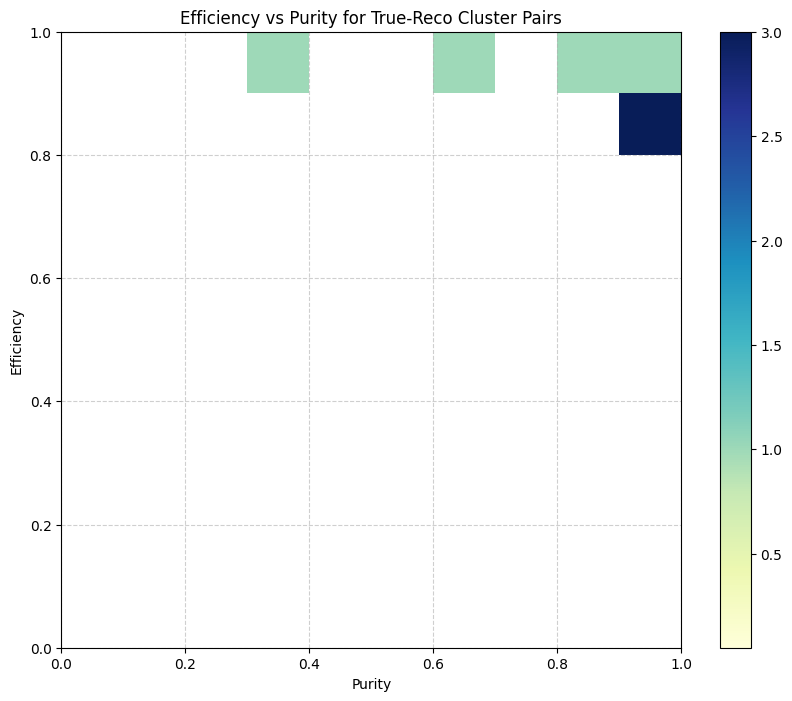

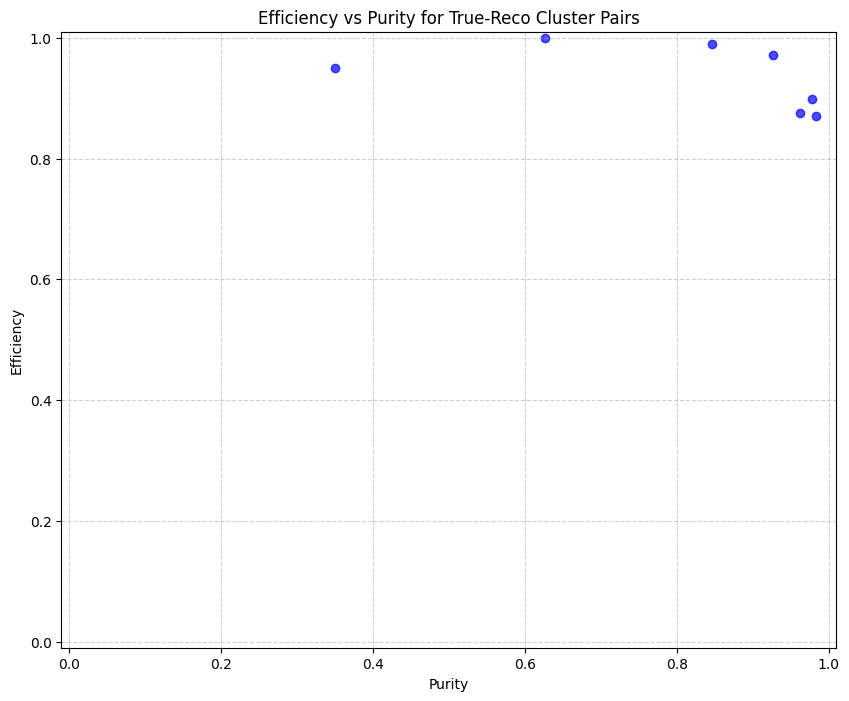

In [61]:
# lets associate and save efficiency and purity values for each true-reco pair in a dictionary for later use
# Create a dictionary to store efficiency and purity for each true-reco pair
performance_dict = {}
# Loop over each matched pair to fill the performance dictionary
for _, row in best_matches.iterrows():
    true_cluster_id = row['true_cluster_id']
    reco_cluster_id = row['reco_cluster_id']
    purity = row['purity']
    efficiency_row = efficiency_df[(efficiency_df['true_cluster_id'] == true_cluster_id) & (efficiency_df['reco_cluster_id'] == reco_cluster_id)]
    if not efficiency_row.empty:
        efficiency = efficiency_row.iloc[0]['efficiency']
        performance_dict[(true_cluster_id, reco_cluster_id)] = {
            'purity': purity,
            'efficiency': efficiency
        }
# Display the performance dictionary
print("Performance Dictionary for True-Reco Cluster Pairs:")
# Convert efficiency and purity results to a DataFrame for easier prints
performance_df = pd.DataFrame([{
    'true_cluster_id': key[0],
    'reco_cluster_id': key[1],
    'purity': value['purity'],
    'efficiency': value['efficiency']
} for key, value in performance_dict.items()])
print(performance_df[['true_cluster_id', 'reco_cluster_id', 'purity', 'efficiency']])

# now lets draw 2D efficiency vs purity plot for these pairs. Not has a scatter plot but as a col histogram where x-axis is purity, y-axis is efficiency and color is number of pairs in that bin of purity and efficiency
plt.figure(figsize=(10, 8))
cmap = plt.cm.YlGnBu.copy()
cmap.set_under('white')
plt.hist2d(performance_df['purity'], performance_df['efficiency'], bins=[10, 10], range=[[0,1],[0,1]], cmap=cmap, vmin=0.05)
plt.xlabel('Purity')
plt.ylabel('Efficiency')
plt.xlim(0.0, 1)
plt.ylim(0.0, 1)
plt.title('Efficiency vs Purity for True-Reco Cluster Pairs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.colorbar()
plt.show(block=False)

plt.figure(figsize=(10, 8))
plt.scatter(performance_df['purity'], performance_df['efficiency'], color='blue', alpha=0.7)
plt.xlabel('Purity')
plt.ylabel('Efficiency')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.title('Efficiency vs Purity for True-Reco Cluster Pairs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(PLOTDIR / f"efficiency_vs_purity_scatter_evt{evt}_{apa}.png")
plt.show(block=False)




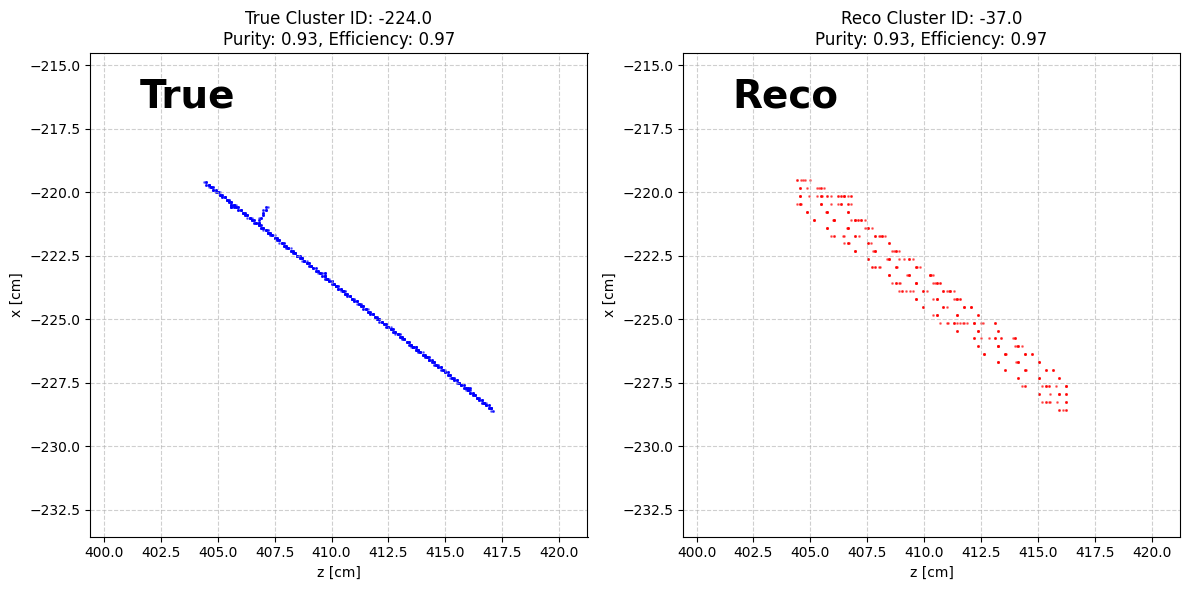

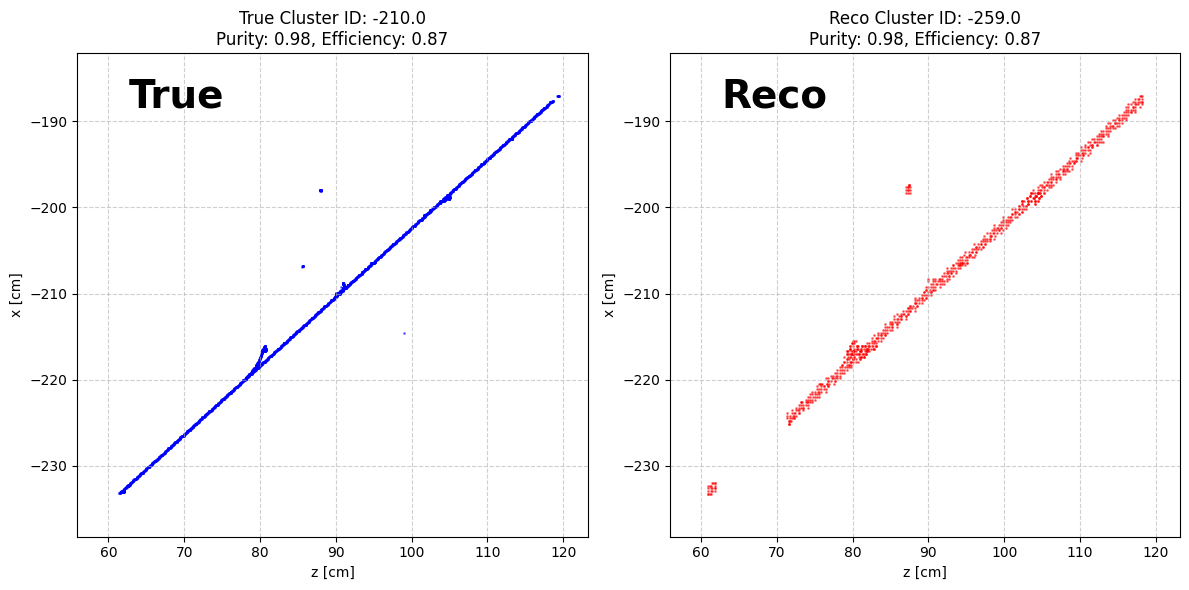

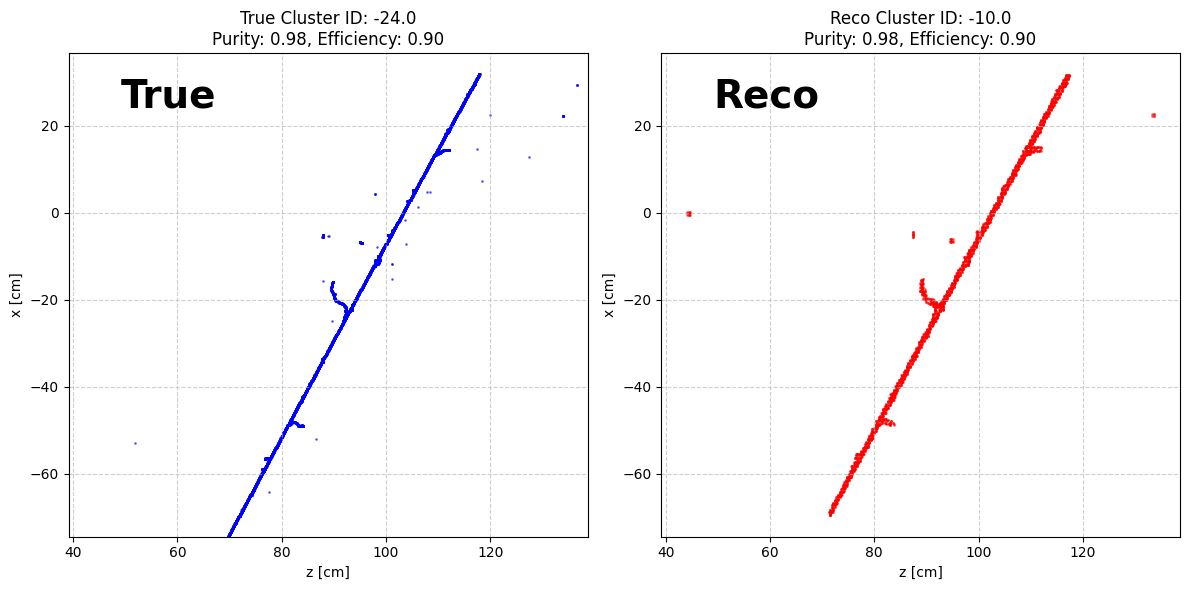

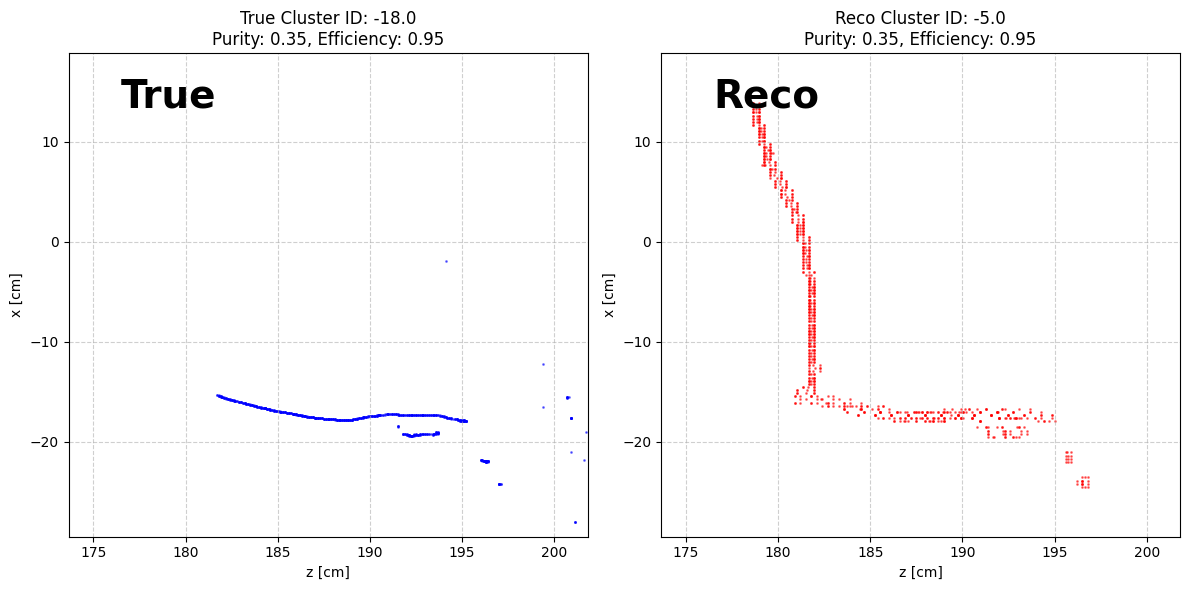

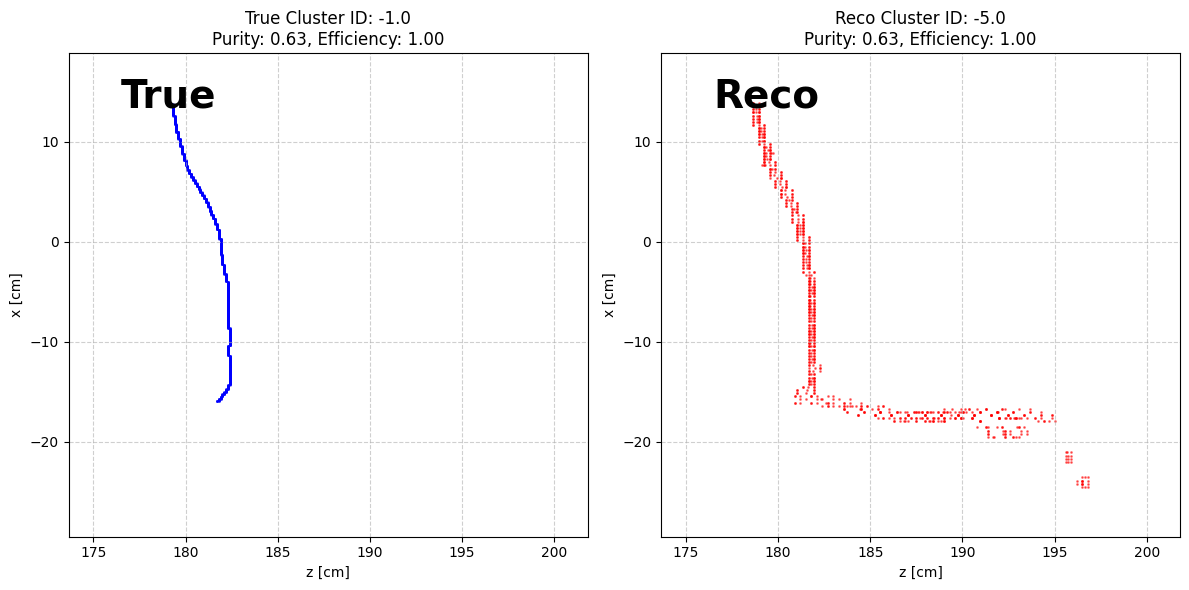

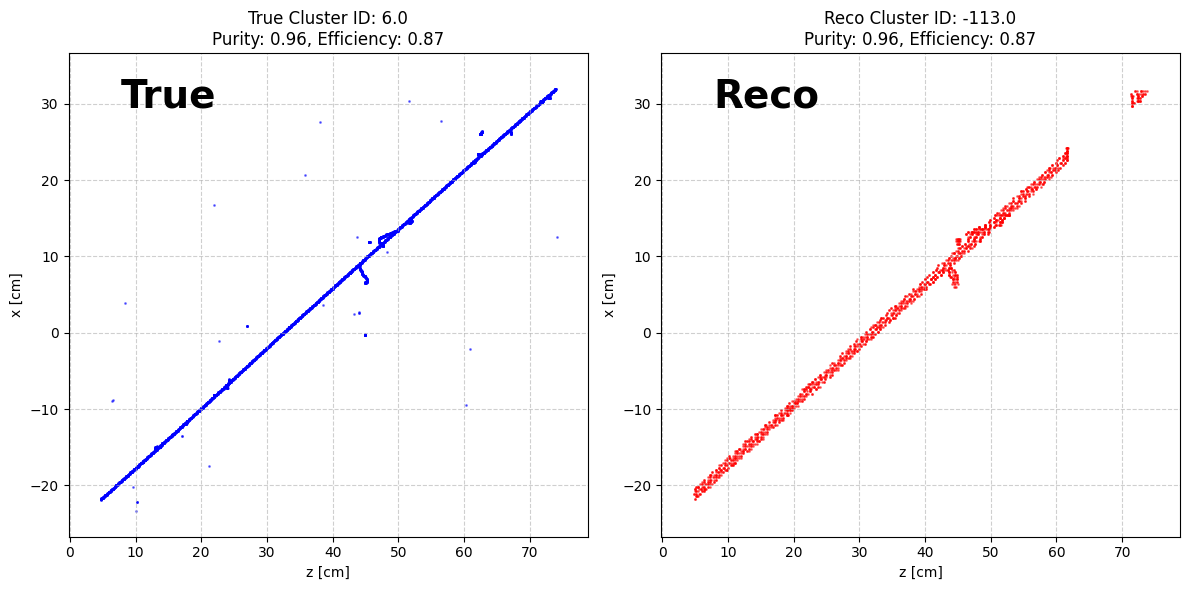

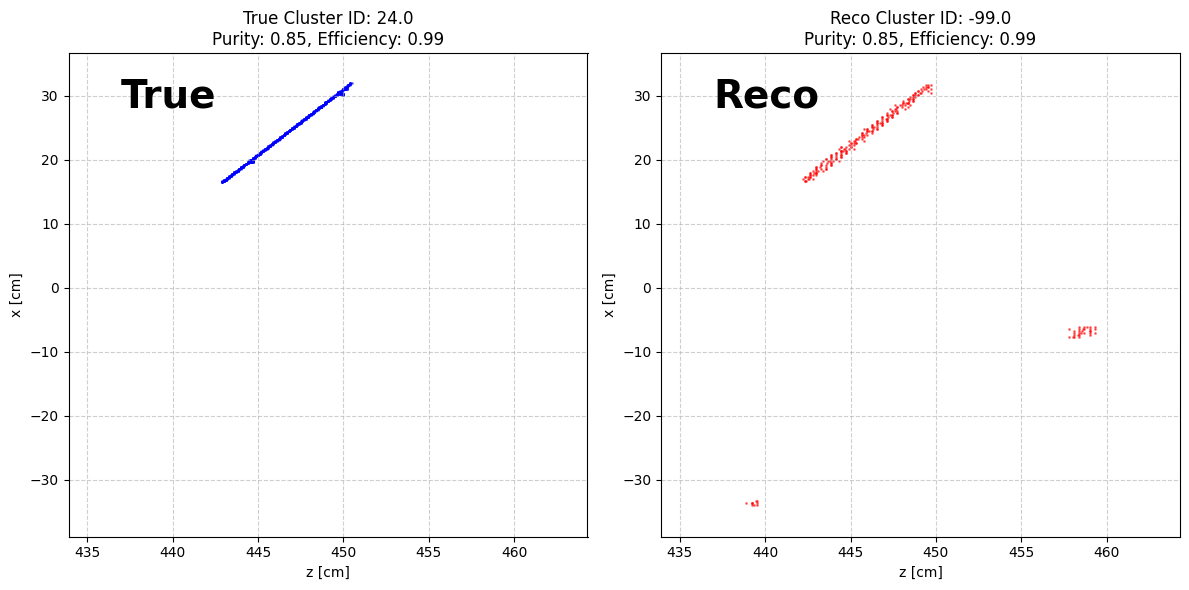

In [62]:
# lets draw each true-reco pair in side by side plots with their efficiency and purity in the title of the plot to visually compare them
# Loop over each matched pair to draw side-by-side plots
for _, row in best_matches.iterrows():
    true_cluster_id = row['true_cluster_id']
    reco_cluster_id = row['reco_cluster_id']
    purity = row['purity']
    efficiency_row = efficiency_df[(efficiency_df['true_cluster_id'] == true_cluster_id) & (efficiency_df['reco_cluster_id'] == reco_cluster_id)]
    if not efficiency_row.empty:
        efficiency = efficiency_row.iloc[0]['efficiency']
        true_points = np.array(clusters_true[true_cluster_id])
        reco_points = np.array(clusters_reco[reco_cluster_id])
        # Create side-by-side plots
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        # True cluster plot
        axes[0].scatter(true_points[:, 2], true_points[:, 0], s=marker_size, color='blue', alpha=0.5)
        # let's write large True label on the true cluster plot and large Reco label on the reco cluster plot
        axes[0].text(0.10, 0.95, "True", transform=axes[0].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
        axes[0].set_title(f'True Cluster ID: {true_cluster_id}\nPurity: {purity:.2f}, Efficiency: {efficiency:.2f}')
        axes[0].set_xlabel('z [cm]')
        axes[0].set_ylabel('x [cm]')
        axes[0].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
        axes[0].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
        axes[0].grid(True, linestyle='--', alpha=0.6)
        # Reco cluster plot
        axes[1].scatter(reco_points[:, 2], reco_points[:, 0], s=marker_size, color='red',alpha=0.5)
        axes[1].text(0.10, 0.95, "Reco", transform=axes[1].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
        axes[1].set_title(f'Reco Cluster ID: {reco_cluster_id}\nPurity: {purity:.2f}, Efficiency: {efficiency:.2f}')
        axes[1].set_xlabel('z [cm]')
        axes[1].set_ylabel('x [cm]')
        axes[1].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
        axes[1].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
        axes[1].grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.savefig(PLOTDIR / f"true_reco_comparison_true{true_cluster_id}_reco{reco_cluster_id}_evt{evt}_{apa}.png")
        plt.show(block=False)